In [1]:
# importacion de librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de los archivos  CSV

In [3]:
df_ads = pd.read_csv('marketing_campaign.csv',sep=';')

# Exploración  del archivo

In [4]:
print('Tamaño del dataset:', df_ads.shape)

Tamaño del dataset: (2240, 29)


In [5]:
print('Información del  archivo:', df_ads.info() )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df_ads.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df_ads.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

# Tratamiento de valores Nulos

In [7]:
# Calculo de la mediana de Income con pandas y relleno los nulos con ese valor
df_ads['Income'] = df_ads['Income'].fillna(df_ads['Income'].median())

In [8]:
# veriificación 
df_ads.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [9]:
# Conversión de la columna Dt_Customer (string -> fecha )
df_ads['Dt_Customer'] = pd.to_datetime(df_ads['Dt_Customer'])

In [10]:
df_ads['Dt_Customer'].dt.year

0       2012
1       2014
2       2013
3       2014
4       2014
        ... 
2235    2013
2236    2014
2237    2014
2238    2014
2239    2012
Name: Dt_Customer, Length: 2240, dtype: int32

In [11]:
# Calculo de edad
df_ads['Age'] = df_ads['Dt_Customer'].dt.year - df_ads['Year_Birth']

In [12]:
# Verificación
df_ads['Age'].describe()

count    2240.000000
mean       44.222321
std        12.022855
min        16.000000
25%        36.000000
50%        43.000000
75%        54.000000
max       121.000000
Name: Age, dtype: float64

El promedio de 44 años tiene sentido, pero hay un cliente de 121 años.
Eso es un outlier — probablemente un error en el dato original de Year_Birth.
Filtramos el dataframe para ver exactamente qué registros tienen una edad mayor a 90 años

In [13]:
age_filtro = df_ads[df_ads['Age'] >= 90]


In [14]:
age_filtro.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,2013-09-26,99,15,...,0,0,0,0,0,1,3,11,0,113
239,11004,1893,2n Cycle,Single,60182.0,0,1,2014-05-17,23,8,...,0,0,0,0,0,0,3,11,0,121
339,1150,1899,PhD,Together,83532.0,0,0,2013-09-26,36,755,...,0,0,1,0,0,0,3,11,0,114


El filtro nos indica que son 3 los registros con años de nacimiento 1893, 1899 y 1900 — claramente errores de carga de datos.
Procedemos a eliminarlos del dataframe. 

In [15]:
# Filtramos el df para quedarnos solo con los registros donde Age sea menor o igual a 90
df_ads = df_ads[df_ads['Age'] <= 90]

In [16]:
# Verificación
print('Verificación de tamaño:', df_ads.shape)

Verificación de tamaño: (2237, 30)


# Revisión de outliers o valores raros

In [17]:
df_ads['Income'].describe()

count      2237.000000
mean      52227.407689
std       25043.266830
min        1730.000000
25%       35523.000000
50%       51381.500000
75%       68281.000000
max      666666.000000
Name: Income, dtype: float64

El máximo de $666.666 no es razonable comparado con la mediana de $51.381, es claramente un outlier — La diferencia con el percentil 75 ($68.281) es enorme.

In [18]:
# Fitración del df para eliminar el outlier
df_ads = df_ads[df_ads['Income'] <= 600000]

In [19]:
print('Verificación de tamaño:', df_ads.shape)

Verificación de tamaño: (2236, 30)


# Revisión de las Categorías Marital_Status y Education

In [20]:
print(df_ads['Marital_Status'].unique())
print(df_ads['Education'].unique())

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']


In [21]:
# Unificación de valores a Single, con un diccionario
df_ads['Marital_Status'] = df_ads['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

In [22]:
# Verificación de valores únicos en Marital_Status
print('Valores unicos en Marital_Status:',df_ads['Marital_Status'].unique())

Valores unicos en Marital_Status: ['Single' 'Together' 'Married' 'Divorced' 'Widow']


In [24]:
# Verificación de valores únicos en Education
print('Valores unicos en Education:',df_ads['Education'].unique())

Valores unicos en Education: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']


'2n Cycle' es un término europeo que equivale a un Master. Hay que normalizar este valor

In [25]:
df_ads['Education'] = df_ads['Education'].replace('2n Cycle', 'Master')

In [26]:
# Verificación de valores únicos
print('Valores unicos en Education:',df_ads['Education'].unique())

Valores unicos en Education: ['Graduation' 'PhD' 'Master' 'Basic']


# Creación de columnas derivadas que nos van a servir para los gráficos y para MySQL.

* Total_Spending = Gasto total sumando todas las columnas de productos

In [27]:
cols_gasto = ['MntWines', 'MntFruits', 'MntMeatProducts', 
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df_ads['Total_Spending'] = df_ads[cols_gasto].sum(axis=1) # El axis=1 le indica que sume por fila (no por columna)

In [28]:
df_ads['Total_Spending'].describe()

count    2236.000000
mean      605.986583
std       601.865156
min         5.000000
25%        69.000000
50%       396.500000
75%      1045.500000
max      2525.000000
Name: Total_Spending, dtype: float64

* Total_Campaigns_Accepted = Total de campañas aceptadas por cliente

In [29]:
cols_campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
              'AcceptedCmp4', 'AcceptedCmp5', 'Response']

df_ads['Total_Campaigns_Accepted'] = df_ads[cols_campaigns].sum(axis=1) # El axis=1 le indica que sume por fila (no por columna)

In [30]:
df_ads['Total_Campaigns_Accepted'].describe()

count    2236.000000
mean        0.447227
std         0.891113
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: Total_Campaigns_Accepted, dtype: float64

* Has_Children = Indica si el cliente tiene hijos en el hogar (ya sean niños o adolescentes)

In [31]:
cols_children = ['Kidhome', 'Teenhome']
df_ads['Has_Children'] = (df_ads[cols_children].sum(axis=1) > 0).astype(int)

# df_ads[cols_children].sum(axis=1)Suma Kidhome + Teenhome por fila
# > 0 Compara si esa suma es mayor a cero → devuelve True o False
# .astype(int)Convierte True → 1 y False → 0

In [32]:
df_ads['Has_Children'].value_counts()

Has_Children
1    1599
0     637
Name: count, dtype: int64

El resultado nos indica que la mayoría de clientes (1599) tiene al menos un hijo en el hogar

Resumen de columnas derivadas creadas:

✅ Age → edad del cliente

✅ Total_Spending → gasto total en productos

✅ Total_Campaigns_Accepted → campañas aceptadas

✅ Has_Children → si tiene hijos (0/1)

# Exportación del Dataset limpio

In [ ]:
df_ads.to_csv('marketing_campaign_clean.csv', index=False, sep=',', decimal='.') # El index=False le indica que no incluya el índice de filas en el archivo exportado

# Gráficos exploratorios para responder las preguntas de negocio

1. ¿Cuál es la distribución de edad de los clientes?

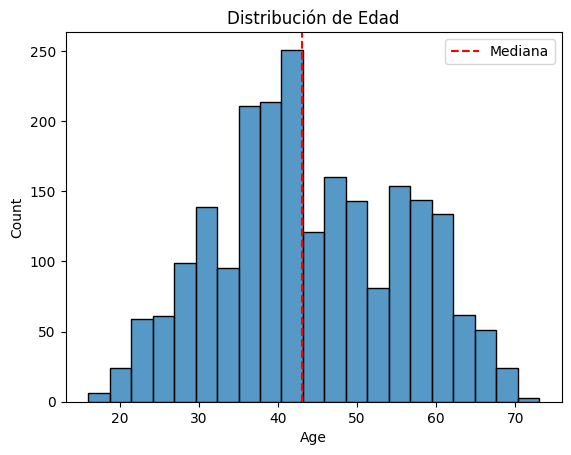

In [33]:
sns.histplot(data=df_ads, x='Age')
plt.axvline(df_ads['Age'].median(), color='red', linestyle='--', label='Mediana')
plt.title('Distribución de Edad')
plt.legend()
plt.show()

2. ¿Cuál es la distribución de Income (Ingresos)?

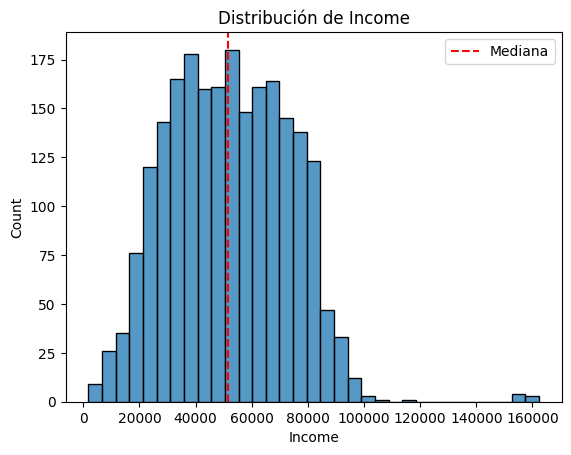

In [34]:
sns.histplot(data=df_ads, x='Income')
plt.axvline(df_ads['Income'].median(), color='red', linestyle='--', label='Mediana')
plt.title('Distribución de Income')
plt.legend()
plt.show()

* Dos observaciones del gráfico:

1. La mayoría de clientes tiene ingresos entre $30K y $80K
2. Hay una pequeña barra suelta cerca de $160K — son clientes con ingresos altos que no llegamos a eliminar como outliers, son legítimos

3. ¿Cuánto gasta cada cliente por categoría de producto?


In [ ]:
# Calculamos el gasto promedio por categoría.
promedio_gasto = df_ads[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].mean()
print(promedio_gasto)


MntWines            304.127460
MntFruits            26.275939
MntMeatProducts     166.983453
MntFishProducts      37.536225
MntSweetProducts     27.080501
MntGoldProds         43.983005
dtype: float64


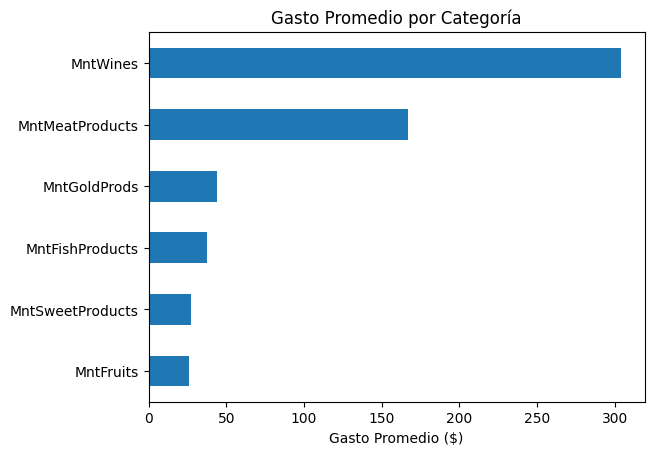

In [36]:
promedio_gasto.sort_values().plot(kind='barh')
plt.title('Gasto Promedio por Categoría')
plt.xlabel('Gasto Promedio ($)')
plt.show()

4. ¿Cuál fue la tasa de aceptación de cada campaña?

In [37]:
promedio_aceptacion = df_ads[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].mean()
print(promedio_aceptacion)

AcceptedCmp1    0.064401
AcceptedCmp2    0.013417
AcceptedCmp3    0.072898
AcceptedCmp4    0.074687
AcceptedCmp5    0.072451
Response        0.149374
dtype: float64


Response es la última campaña y tiene un 14.9% de aceptación — más del doble que cualquier otra. Este es un insight importante para el negocio

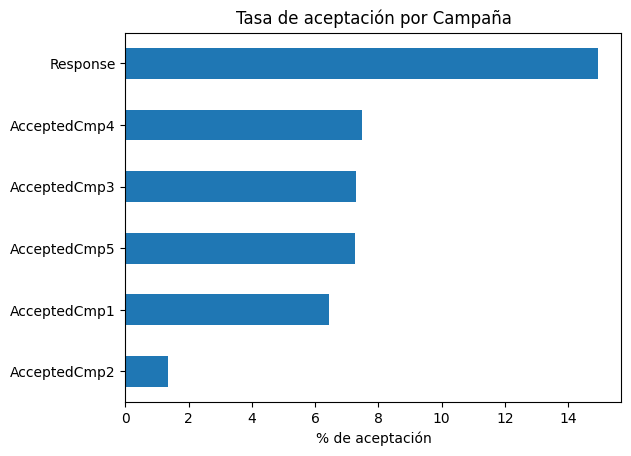

In [38]:
(promedio_aceptacion * 100).sort_values().plot(kind='barh')
plt.title('Tasa de aceptación por Campaña')
plt.xlabel('% de aceptación')
plt.show()

5. ¿Cuál fue la tasa de aceptación de cada campaña?

In [39]:
gasto_hijos = df_ads.groupby('Has_Children')[cols_gasto].mean()
print(gasto_hijos)

                MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Has_Children                                                            
0             486.885400  52.213501       372.312402        76.503925   
1             231.321451  15.943089        85.185741        22.012508   

              MntSweetProducts  MntGoldProds  
Has_Children                                  
0                    53.043956     63.897959  
1                    16.737336     36.049406  


 Los clientes sin hijos tienen más ingreso disponible para gastar en productos premium como vinos y carnes.

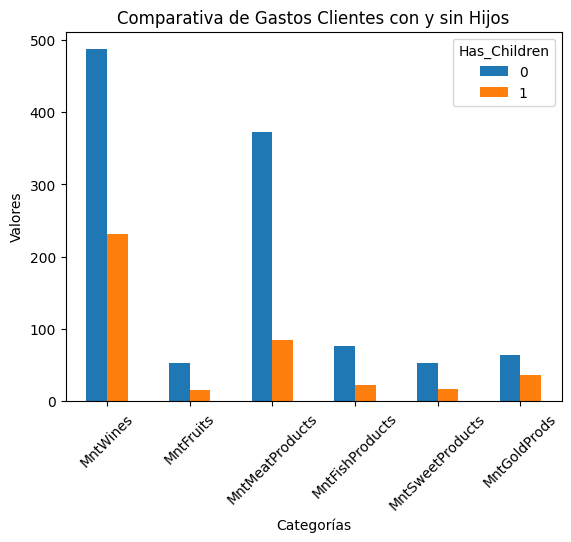

In [50]:
gasto_hijos.T.plot(kind='bar',rot=45) # gasto_hijos.T.plot(kind='bar')
plt.title('Comparativa de Gastos Clientes con y sin Hijos')
plt.xlabel('Categorías')
plt.ylabel('Valores')
plt.show()

6. ¿Qué canal de compra usan más los clientes?

In [51]:
# Calculamos el gasto promedio por canal de compra.
promedio_canal = df_ads[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean()
print(promedio_canal)

NumDealsPurchases      2.326029
NumWebPurchases        4.087657
NumCatalogPurchases    2.663238
NumStorePurchases      5.795617
dtype: float64


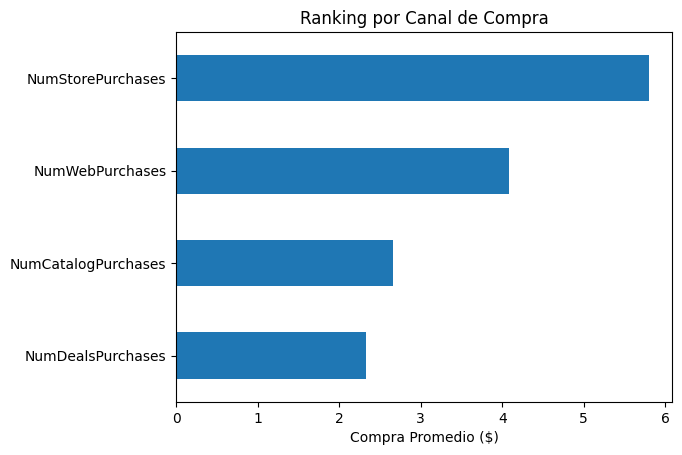

In [53]:
promedio_canal.sort_values().plot(kind='barh')
plt.title('Ranking por Canal de Compra')
plt.xlabel('Compra Promedio ($)')
plt.show()

Mapa de Correlaciones (Heatmap)

In [ ]:
df_ads.corr(numeric_only=True) # numeric_only=True para seleccionar sólo las columnas numéricas

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Total_Campaigns_Accepted,Has_Children
ID,1.000000,0.002659,0.000869,0.001656,-0.003052,-0.046300,-0.020726,0.007247,-0.002274,-0.022903,...,-0.021392,-0.014970,0.031580,NaN,NaN,-0.021596,-0.003087,-0.015359,-0.035773,-0.001476
Year_Birth,0.002659,1.000000,-0.198835,0.233894,-0.363172,-0.019396,-0.162809,-0.013657,-0.030729,-0.042359,...,-0.008146,-0.007621,-0.004450,NaN,NaN,0.018557,-0.998298,-0.113618,0.007549,0.011097
Income,0.000869,-0.198835,1.000000,-0.510441,0.034315,0.007829,0.686080,0.504911,0.684176,0.518462,...,0.325254,0.104062,-0.027871,NaN,NaN,0.161121,0.199753,0.789375,0.342081,-0.401361
Kidhome,0.001656,0.233894,-0.510441,1.000000,-0.035339,0.007964,-0.496166,-0.372442,-0.436901,-0.387404,...,-0.172435,-0.081760,0.036336,NaN,NaN,-0.080005,-0.230008,-0.556719,-0.193112,0.520676
Teenhome,-0.003052,-0.363172,0.034315,-0.035339,1.000000,0.016746,0.005047,-0.176117,-0.261171,-0.204177,...,-0.140426,-0.015715,0.007553,NaN,NaN,-0.154941,0.361505,-0.138197,-0.159228,0.587375
Recency,-0.046300,-0.019396,0.007829,0.007964,0.016746,1.000000,0.016321,-0.003717,0.023446,0.001314,...,-0.019367,-0.001811,0.005361,NaN,NaN,-0.198781,0.017845,0.020842,-0.088973,0.000208
MntWines,-0.020726,-0.162809,0.686080,-0.496166,0.005047,0.016321,1.000000,0.388472,0.561886,0.398956,...,0.354328,0.206031,-0.035974,NaN,NaN,0.247280,0.153321,0.891696,0.488823,-0.342780
MntFruits,0.007247,-0.013657,0.504911,-0.372442,-0.176117,-0.003717,0.388472,1.000000,0.542030,0.594415,...,0.195351,-0.009717,-0.002813,NaN,NaN,0.125854,0.010415,0.613122,0.172027,-0.412210
MntMeatProducts,-0.002274,-0.030729,0.684176,-0.436901,-0.261171,0.023446,0.561886,0.542030,1.000000,0.567813,...,0.310053,0.043060,-0.020750,NaN,NaN,0.236548,0.025841,0.842624,0.329636,-0.574356
MntFishProducts,-0.022903,-0.042359,0.518462,-0.387404,-0.204177,0.001314,0.398956,0.594415,0.567813,1.000000,...,0.260866,0.002555,-0.018842,NaN,NaN,0.111325,0.038298,0.642335,0.179435,-0.450162


* Las columnas 'Z_CostContact' y 'Z_Revenue' tienen todos NaN — no aportan nada. Hay que excluirlas.
* Seleccionamos solo las más relevantes para el negocio.



In [56]:
cols_corr = ['Income', 'Age', 'Total_Spending', 'Total_Campaigns_Accepted',
             'Has_Children', 'Recency', 'NumWebPurchases', 
             'NumStorePurchases', 'NumCatalogPurchases', 'Response']

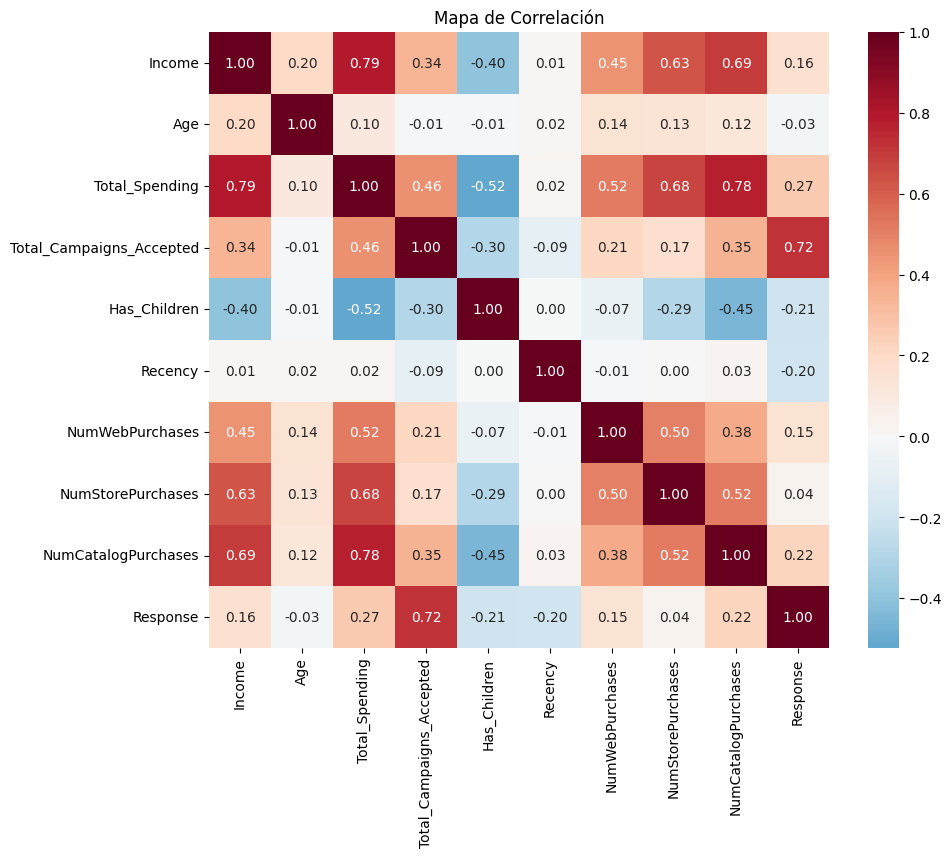

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_ads[cols_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Mapa de Correlación')
plt.show()

# Resumen del EDA

✅ Carga y limpieza del dataset

✅ Tratamiento de nulos y outliers

✅ Columnas derivadas

✅ 6 gráficos exploratorios

✅ Mapa de correlaciones

## Conclusiones del EDA

1. Perfil típico del cliente: La distribución de edad se concentra entre los 40 y 45 años. La mediana de ingresos es de $51.381 anuales y la mayoría cuenta con estudios universitarios (Graduation).
2. Categorías de producto: Los vinos lideran ampliamente el gasto promedio por cliente, seguidos por las carnes. Las frutas y dulces son las categorías menos relevantes.
3. Campañas: La última campaña (Response) fue la más exitosa con un 14,9% de aceptación, más del doble que cualquier otra. La Campaña 2 fue la de peor desempeño con apenas el 1,3%.
4. Impacto de los hijos: Los clientes sin hijos tienen mayor poder adquisitivo y gastan significativamente más, especialmente en vinos y carnes. Los clientes con hijos muestran menor respuesta a las campañas y menor gasto general.
5. Canales de compra: La tienda física es el canal preferido, seguida de cerca por la web. El catálogo y las compras con descuento tienen menor participación.